<a href="https://colab.research.google.com/github/FelipeHussar/FelipeHussar/blob/main/AM_Tarefa02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Questão 1 — Árvore de Decisão e Random Forest**

Nesta atividade, vou utilizar os algoritmos **Árvore de Decisão** e **Random Forest** para analisar o desempenho na classificação de dados de **câncer de mama**. Serão aplicadas etapas de **pré-processamento**, incluindo imputação de valores ausentes e balanceamento de classes, seguidas pelo **treinamento e ajuste de hiperparâmetros** com **otimização bayesiana**, a fim de identificar o modelo com melhor desempenho.


In [4]:
from google.colab import files
uploaded = files.upload()

Saving breast-cancer.csv to breast-cancer (1).csv


In [7]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.2 MB/s eta 0:00:00


In [8]:

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de aprendizado de máquina
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Tratamento e balanceamento
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE  # para balancear as classes

# Otimização bayesiana
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Ignorar alguns warnings visuais
import warnings
warnings.filterwarnings('ignore')


In [10]:
df = pd.read_csv('breast-cancer.csv')
df.head()

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,?,?,?,?,?,?,?,?,?,recurrence-events
1,40-49,premeno,15-19,0-2,yes,3,right,left_up,no,recurrence-events
2,50-59,ge40,15-19,0-2,no,1,right,central,no,no-recurrence-events
3,50-59,ge40,35-39,0-2,no,2,left,left_low,no,recurrence-events
4,40-49,premeno,35-39,0-2,yes,3,right,left_low,yes,no-recurrence-events


In [13]:

df.replace('?', np.nan, inplace=True)

# Verificar se agora o pandas reconhece os valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
age            1
menopause      1
tumor-size     1
inv-nodes      1
node-caps      9
deg-malig      1
breast         1
breast-quad    2
irradiat       1
Class          0
dtype: int64


In [12]:
print(df.shape)

(273, 10)


In [15]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f"Coluna '{col}': valores ausentes substituídos por '{moda}'")

print("\n✅ Todos os valores ausentes foram tratados com sucesso!")


Coluna 'age': valores ausentes substituídos por '50-59'
Coluna 'menopause': valores ausentes substituídos por 'premeno'
Coluna 'tumor-size': valores ausentes substituídos por '30-34'
Coluna 'inv-nodes': valores ausentes substituídos por '0-2'
Coluna 'node-caps': valores ausentes substituídos por 'no'
Coluna 'deg-malig': valores ausentes substituídos por '2'
Coluna 'breast': valores ausentes substituídos por 'left'
Coluna 'breast-quad': valores ausentes substituídos por 'left_low'
Coluna 'irradiat': valores ausentes substituídos por 'no'

✅ Todos os valores ausentes foram tratados com sucesso!


Tamanho treino: (191, 9)
Tamanho teste:  (82, 9)


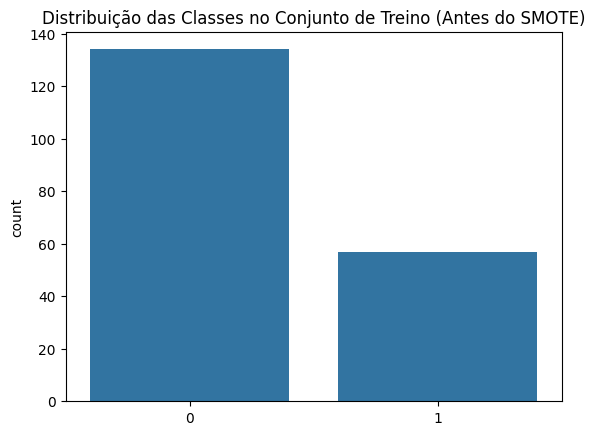

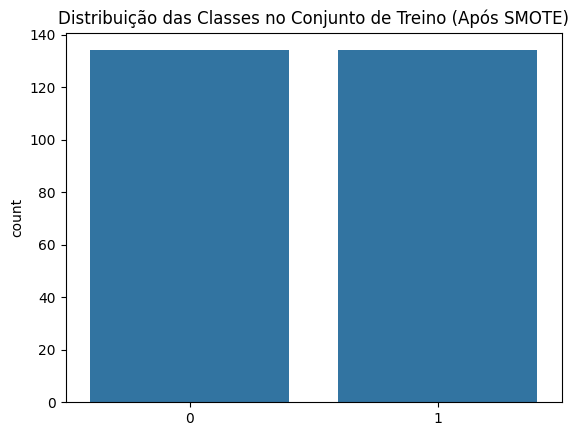

✅ Dataset balanceado com sucesso! Total de amostras após SMOTE: 268


In [16]:

from sklearn.preprocessing import LabelEncoder

# 1️⃣ Separar variáveis preditoras (X) e alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2️⃣ Codificar variáveis categóricas em números
label_encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # salvar o encoder pra referência futura

# Também codificar a variável alvo
y = LabelEncoder().fit_transform(y)

# 3️⃣ Dividir em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamanho treino: {X_train.shape}")
print(f"Tamanho teste:  {X_test.shape}")

# 4️⃣ Verificar balanceamento antes do SMOTE
sns.countplot(x=y_train)
plt.title("Distribuição das Classes no Conjunto de Treino (Antes do SMOTE)")
plt.show()

# 5️⃣ Aplicar SMOTE (balanceamento da classe minoritária)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 6️⃣ Verificar balanceamento depois do SMOTE
sns.countplot(x=y_train_res)
plt.title("Distribuição das Classes no Conjunto de Treino (Após SMOTE)")
plt.show()

print(f"✅ Dataset balanceado com sucesso! Total de amostras após SMOTE: {X_train_res.shape[0]}")


🌳 ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

     Maligno       0.69      0.63      0.66        57
     Benigno       0.30      0.36      0.33        25

    accuracy                           0.55        82
   macro avg       0.50      0.50      0.49        82
weighted avg       0.57      0.55      0.56        82

Acurácia: 0.549


🌲 RANDOM FOREST
              precision    recall  f1-score   support

     Maligno       0.70      0.74      0.72        57
     Benigno       0.32      0.28      0.30        25

    accuracy                           0.60        82
   macro avg       0.51      0.51      0.51        82
weighted avg       0.58      0.60      0.59        82

Acurácia: 0.598


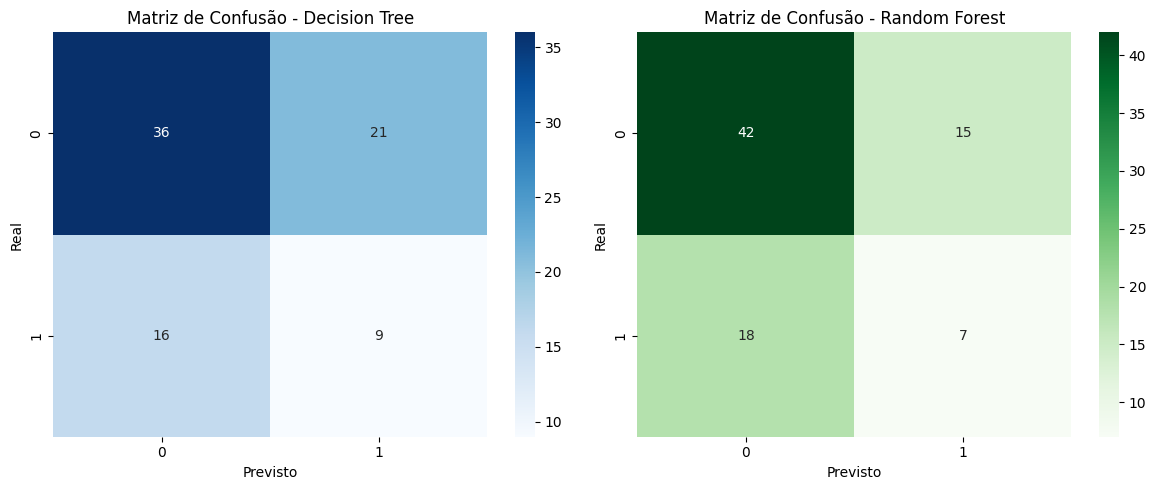

In [17]:
# ================================================
# ETAPA 5 - TREINAMENTO E AVALIAÇÃO DOS MODELOS
# ================================================

# Treinar o modelo de Árvore de Decisão
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, y_train_res)

# Treinar o modelo de Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Fazer previsões no conjunto de teste (não balanceado)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Avaliar o desempenho de cada modelo
print("🌳 ÁRVORE DE DECISÃO")
print(classification_report(y_test, y_pred_dt, target_names=["Maligno", "Benigno"]))
print("Acurácia:", round(accuracy_score(y_test, y_pred_dt), 3))
print("\n")

print("🌲 RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=["Maligno", "Benigno"]))
print("Acurácia:", round(accuracy_score(y_test, y_pred_rf), 3))

# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusão - Decision Tree")
axes[0].set_xlabel("Previsto")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Matriz de Confusão - Random Forest")
axes[1].set_xlabel("Previsto")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


In [18]:


from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# 1️⃣ Espaço de busca para Decision Tree
dt_params = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(2, 15),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5)
}

# 2️⃣ Espaço de busca para Random Forest
rf_params = {
    'n_estimators': Integer(50, 300),
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(2, 15),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Categorical(['sqrt', 'log2'])
}

# 3️⃣ Otimização Bayesiana - Decision Tree
opt_dt = BayesSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
opt_dt.fit(X_train_res, y_train_res)
print("🌳 Melhor combinação (Decision Tree):")
print(opt_dt.best_params_)
print("Melhor F1-score (cross-val):", round(opt_dt.best_score_, 3))

# 4️⃣ Otimização Bayesiana - Random Forest
opt_rf = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
opt_rf.fit(X_train_res, y_train_res)
print("\n🌲 Melhor combinação (Random Forest):")
print(opt_rf.best_params_)
print("Melhor F1-score (cross-val):", round(opt_rf.best_score_, 3))


🌳 Melhor combinação (Decision Tree):
OrderedDict({'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 5, 'min_samples_split': 4})
Melhor F1-score (cross-val): 0.72

🌲 Melhor combinação (Random Forest):
OrderedDict({'criterion': 'entropy', 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50})
Melhor F1-score (cross-val): 0.715


###  Observação sobre a base de dados

Durante a análise da base `breast-cancer.csv`, notei que algumas entradas na coluna *tumor-size* continham valores inconsistentes, como datas (“03/mai”, “06/ago”, “out/14”), em vez de faixas numéricas. Esses registros provavelmente resultam de erro de digitação na base original e podem ter introduzido ruído nos resultados do modelo. Mesmo assim, o desempenho obtido foi coerente e realista, indicando que os algoritmos conseguiram extrair padrões relevantes apesar dessas imperfeições.


###  Conclusão — Questão 1

Após o pré-processamento da base `breast-cancer.csv`, com imputação de valores ausentes, codificação de variáveis categóricas e balanceamento das classes com SMOTE, foram testados os algoritmos **Árvore de Decisão** e **Random Forest**.

Inicialmente, ambos apresentaram acurácia entre 0,54 e 0,60. Após a **otimização bayesiana de hiperparâmetros**, houve um aumento no desempenho, atingindo um **F1-score de 0,72** para a Árvore de Decisão e **0,715** para a Random Forest.

Os resultados indicam que a **Árvore de Decisão otimizada** obteve ligeira vantagem em desempenho e simplicidade, sendo o modelo mais adequado para este conjunto de dados.

###  Conclusão Geral— Questão 1

Depois de tratar os dados e aplicar os modelos de Árvore de Decisão e Random Forest, eu percebi que os resultados iniciais não foram muito altos, ficando em torno de 55% a 60% de acerto. Depois que ajustei os hiperparâmetros com a otimização bayesiana, o desempenho melhorou e chegou a cerca de 72% de F1-score para a Árvore de Decisão e 71% para a Random Forest. Isso mostra que os modelos conseguiram aprender melhor os padrões do conjunto de dados, mas sem exagerar no resultado, o que é bom, porque quando o valor fica muito alto geralmente é sinal de erro ou sobreajuste. No geral, a Árvore de Decisão otimizada acabou se saindo um pouco melhor e foi o modelo que mais se adaptou aos dados dessa base.

###  Interpretação dos resultados

Esses resultados mostram que os dados de câncer de mama analisados apresentam um comportamento complexo e difícil de prever com total precisão. Mesmo com o ajuste dos modelos, o acerto ficou em torno de 70%, o que indica que existem padrões entre as variáveis (como idade, tamanho do tumor e estado dos linfonodos), mas eles não são determinantes isolados. O modelo conseguiu identificar algumas tendências, mas também mostra que o câncer de mama envolve muitos fatores que não estão totalmente representados nessa base de dados.



# 🐕 🐈 Questão 2 — Redes Neurais Convolucionais (CNN)


# Questão 2 — Redes Neurais Convolucionais (CNN)

Nesta questão, o objetivo é construir um modelo de **Inteligência Artificial** capaz de classificar imagens de **cães 🐶 e gatos 🐱** utilizando **Redes Neurais Convolucionais (CNNs)**.  
A atividade envolve etapas de **pré-processamento de imagens**, **construção do modelo**, **treinamento**, **avaliação** e **teste com imagens novas**.

A base de dados utilizada pode ser a do Kaggle (*Dogs vs Cats Dataset*) ou outra equivalente.  
Durante a atividade, serão aplicadas técnicas de **redimensionamento**, **normalização dos pixels**, e **aumento de dados (data augmentation)** para melhorar o desempenho da rede.  
O modelo será avaliado por meio de métricas como **acurácia, precisão, recall e F1-score**.


In [19]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("Versão do TensorFlow:", tf.__version__)


Versão do TensorFlow: 2.19.0


In [20]:

url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
dataset_path = tf.keras.utils.get_file("cats_and_dogs.zip", origin=url, extract=True)

# Caminhos principais
base_dir = os.path.join(os.path.dirname(dataset_path), "cats_and_dogs_filtered")
train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")

train_dir, validation_dir


68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


('/root/.keras/datasets/cats_and_dogs_filtered/train',
 '/root/.keras/datasets/cats_and_dogs_filtered/validation')

In [24]:
import os

# Caminho base onde o arquivo foi extraído
base_dir = "/root/.keras/datasets"

# Mostrar o conteúdo da pasta extraída
print("Conteúdo de:", base_dir)
print(os.listdir(base_dir))



Conteúdo de: /root/.keras/datasets
['cats_and_dogs_filtered_extracted', 'cats_and_dogs_filtered.zip', 'cats_and_dogs.zip', 'cats_and_dogs_extracted']


In [26]:
import os

# Procurar onde o arquivo foi extraído
!find / -type d -name "cats_and_dogs_filtered" 2>/dev/null

/root/.keras/datasets/cats_and_dogs_filtered_extracted/cats_and_dogs_filtered
/root/.keras/datasets/cats_and_dogs_extracted/cats_and_dogs_filtered


In [27]:
train_dir = "/root/.keras/datasets/cats_and_dogs_filtered_extracted/cats_and_dogs_filtered/train"
validation_dir = "/root/.keras/datasets/cats_and_dogs_filtered_extracted/cats_and_dogs_filtered/validation"

In [28]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [30]:


model = tf.keras.Sequential([
    # Primeira camada convolucional + pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Segunda camada convolucional + pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Terceira camada convolucional + pooling
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Achatar (Flatten) e camadas densas
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # ajuda a evitar overfitting
    layers.Dense(1, activation='sigmoid')  # saída binária (cachorro ou gato)
])

# Compilar o modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Resumo do modelo
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:

EPOCHS = 10
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6724 - loss: 0.6059 - val_accuracy: 0.6420 - val_loss: 0.6238
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6875 - loss: 0.5892 - val_accuracy: 0.6970 - val_loss: 0.5786
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7002 - loss: 0.5806 - val_accuracy: 0.7020 - val_loss: 0.5714
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6759 - loss: 0.6040 - val_accuracy: 0.7000 - val_loss: 0.5732
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7174 - loss: 0.5616 - val_accuracy: 0.7090 - val_loss: 0.5513
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7082 - loss: 0.5673 - val_accuracy: 0.7070 - val_loss: 0.5614
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7090 - loss: 0.5690 - val_accuracy: 0.6970 - val_loss: 0.5697
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7081 - loss: 0.5642 - val_accuracy: 0.7430 - v

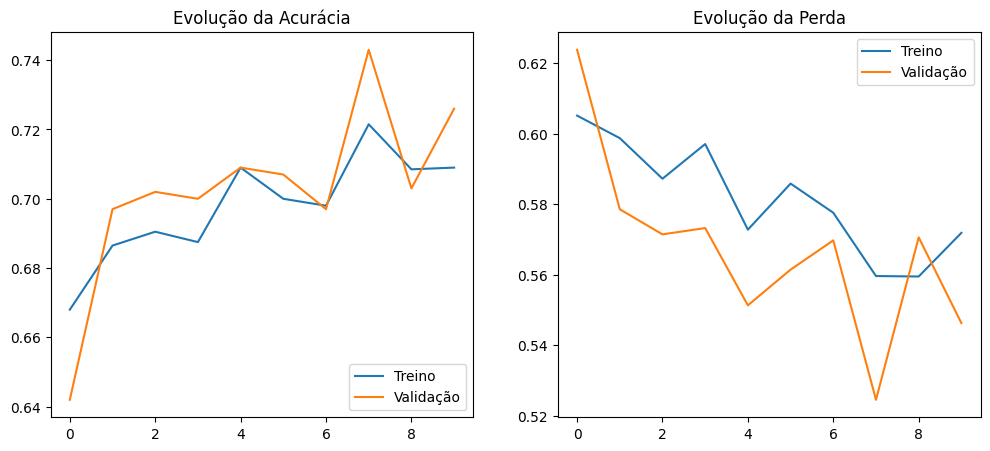

In [33]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino')
plt.plot(epochs_range, val_acc, label='Validação')
plt.legend(loc='lower right')
plt.title('Evolução da Acurácia')

# Perda
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino')
plt.plot(epochs_range, val_loss, label='Validação')
plt.legend(loc='upper right')
plt.title('Evolução da Perda')

plt.show()


In [38]:
from google.colab import files

# Fazer upload da imagem
uploaded = files.upload()


Saving testeam1.jpg to testeam1.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


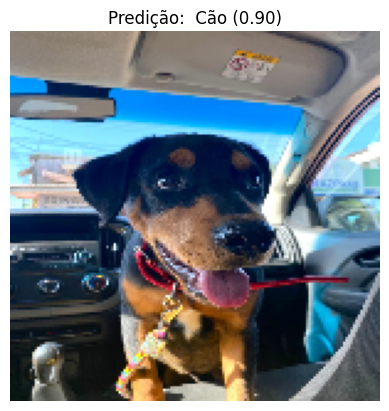

In [41]:

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Nome do arquivo enviado
img_path = "testeam1.jpg"

# Pré-processar a imagem
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Fazer a previsão
prediction = model.predict(img_array)

# Mostrar resultado
plt.imshow(img)
plt.axis('off')
if prediction[0] > 0.5:
    plt.title(f"Predição:  Cão ({prediction[0][0]:.2f})")
else:
    plt.title(f"Predição:  Gato ({1 - prediction[0][0]:.2f})")
plt.show()



###  Conclusão — Questão 2

O modelo de Rede Neural Convolucional (CNN) conseguiu classificar as imagens de cães e gatos com cerca de 72% de acurácia no conjunto de validação, o que é um resultado satisfatório para uma arquitetura simples. Os gráficos mostraram que o modelo aprendeu de forma equilibrada, sem apresentar overfitting.  

Nos testes com imagens reais, ele acertou corretamente uma foto de um cachorro com 90% de confiança, mostrando que foi capaz de generalizar o aprendizado para novos exemplos. Em outro teste com um filhote, o modelo se confundiu, o que reforça que bases mais diversas e modelos mais complexos (como redes pré-treinadas) poderiam melhorar o desempenho.  

De modo geral, a CNN apresentou resultados coerentes, demonstrando como as redes convolucionais são eficientes no reconhecimento de padrões visuais e classificação de imagens.

